In [1]:
!pip install -q grad-cam albumentations torchinfo
print('✅ Dependencies installed')

✅ Dependencies installed


In [2]:
import os, cv2, json, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchinfo import summary

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {device}')
if torch.cuda.is_available():
    print(f'   GPU  : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── LOCAL PATHS (Jupyter) ──────────────────────────────────────
# Dataset folders are in the SAME folder as this notebook
BASE_DIR   = os.getcwd()          # current notebook directory
DATA_ROOT  = BASE_DIR             # train/val/test are directly here
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')
OUT_DIR    = os.path.join(BASE_DIR, 'neoscan_skin_output')

for d in [f'{OUT_DIR}/checkpoints', f'{OUT_DIR}/gradcam', f'{OUT_DIR}/plots']:
    os.makedirs(d, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 4
EPOCHS      = 60
LR          = 1e-4
PATIENCE    = 10
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
CLASS_NAMES  = ['anemia', 'cyanosis', 'jaundice', 'normal']
CLASS_COLORS = {
    'anemia'  :'#E8A0A0',
    'cyanosis':'#64B5F6',
    'jaundice':'#FFD54F',
    'normal'  :'#81C784'
}
print(f'✅ Config ready')
print(f'   TRAIN : {TRAIN_DIR}')
print(f'   VAL   : {VAL_DIR}')
print(f'   TEST  : {TEST_DIR}')
print(f'   OUTPUT: {OUT_DIR}')


✅ Device : cpu
✅ Config ready
   TRAIN : C:\Users\nksha\Downloads\train
   VAL   : C:\Users\nksha\Downloads\val
   TEST  : C:\Users\nksha\Downloads\test
   OUTPUT: C:\Users\nksha\Downloads\neoscan_skin_output


In [3]:
# ── Dataset Verification ──────────────────────────────────────
print("=" * 50)
print("   NEOSCAN AI — SKIN MODULE DATASET CHECK")
print("=" * 50)

all_ok = True
for split, path in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR), ('TEST', TEST_DIR)]:
    print(f"\n{split}:")
    if not os.path.exists(path):
        print(f"  ❌ Folder not found: {path}")
        all_ok = False
        continue
    for cls in CLASS_NAMES:
        cls_path = os.path.join(path, cls)
        if os.path.exists(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])
            print(f"  ✅ {cls:<12} → {n} images")
        else:
            print(f"  ❌ {cls:<12} → NOT FOUND")
            all_ok = False

print("=" * 50)
if all_ok:
    print("✅ All folders found! Ready to train.")
else:
    print("❌ Some folders missing. Check your directory structure.")
    print(f"   Expected structure inside: {BASE_DIR}")
    print("   train/anemia/, train/cyanosis/, train/jaundice/, train/normal/")
    print("   val/anemia/,   val/cyanosis/,   val/jaundice/,   val/normal/")
    print("   test/anemia/,  test/cyanosis/,  test/jaundice/,  test/normal/")


   NEOSCAN AI — SKIN MODULE DATASET CHECK

TRAIN:
  ✅ anemia       → 698 images
  ✅ cyanosis     → 696 images
  ✅ jaundice     → 700 images
  ✅ normal       → 968 images

VAL:
  ✅ anemia       → 120 images
  ✅ cyanosis     → 21 images
  ✅ jaundice     → 30 images
  ✅ normal       → 210 images

TEST:
  ✅ anemia       → 120 images
  ✅ cyanosis     → 22 images
  ✅ jaundice     → 30 images
  ✅ normal       → 210 images
✅ All folders found! Ready to train.


In [4]:
!pip install -q tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


In [5]:
import numpy as np
import os, cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tqdm import tqdm
import pandas as pd

print("Loading MobileNetV2 classifier...")
classifier = MobileNetV2(weights='imagenet', include_top=True)
print("✅ Ready!\n")

# ── LOCAL PATHS (fixed for Jupyter) ──────────────────────────
OUTPUT  = TRAIN_DIR   # already defined in Cell 1 as local path
CLASSES = CLASS_NAMES # already defined in Cell 1

SKIN_KEYWORDS = [
    'skin', 'hand', 'finger', 'nail', 'body', 'face', 'arm',
    'leg', 'neck', 'chest', 'back', 'human', 'person', 'bandage',
    'wound', 'rash', 'lesion', 'sore', 'freckle', 'mole', 'wrist'
]
EYE_KEYWORDS = [
    'eye', 'iris', 'pupil', 'retina', 'cornea', 'optic',
    'lens', 'sclera', 'eyelid', 'eyeball', 'microscope'
]
IRRELEVANT_KEYWORDS = [
    'car', 'dog', 'cat', 'bird', 'tree', 'food', 'building',
    'phone', 'computer', 'table', 'chair', 'mountain', 'ocean'
]

def classify_image_content(img_path):
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x   = preprocess_input(np.expand_dims(image.img_to_array(img), axis=0))
        top3   = decode_predictions(classifier.predict(x, verbose=0), top=3)[0]
        labels = [label.lower() for (_, label, _) in top3]
        is_eye        = any(kw in ' '.join(labels) for kw in EYE_KEYWORDS)
        is_irrelevant = any(kw in ' '.join(labels) for kw in IRRELEVANT_KEYWORDS)
        is_skin       = any(kw in ' '.join(labels) for kw in SKIN_KEYWORDS)
        if is_eye:          category = 'EYE ❌'
        elif is_irrelevant: category = 'IRRELEVANT ❌'
        elif is_skin:       category = 'SKIN ✅'
        else:               category = 'UNCERTAIN ⚠️'
        return {'top_label': labels[0], 'confidence': float(top3[0][2]),
                'category': category, 'all_labels': labels}
    except:
        return {'top_label': 'error', 'confidence': 0,
                'category': 'ERROR', 'all_labels': []}

results, all_records = {}, []
for cls in CLASSES:
    cls_dir = os.path.join(OUTPUT, cls)   # fixed: OUTPUT is already TRAIN_DIR
    if not os.path.exists(cls_dir):
        print(f"❌ Folder not found: {cls_dir}")
        continue
    imgs   = [f for f in os.listdir(cls_dir)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sample = imgs[:50]
    print(f"\n🔍 Scanning {cls.upper()} ({len(sample)} samples)...")
    counts = {'SKIN ✅':0,'EYE ❌':0,'IRRELEVANT ❌':0,'UNCERTAIN ⚠️':0,'ERROR':0}
    for img_name in tqdm(sample, desc=f"  {cls}"):
        result = classify_image_content(os.path.join(cls_dir, img_name))
        counts[result['category']] = counts.get(result['category'], 0) + 1
        all_records.append({'class': cls, 'filename': img_name,
                            'top_label': result['top_label'],
                            'confidence': result['confidence'],
                            'category': result['category']})
    results[cls] = {'counts': counts}
    print(f"  Results: {counts}")

# ── Save report locally (fixed path) ─────────────────────────
df_all       = pd.DataFrame(all_records)
report_path  = os.path.join(BASE_DIR, 'image_scan_report.csv')
df_all.to_csv(report_path, index=False)
print(f"\n💾 Scan report saved → {report_path}")
print(f"   Total images scanned : {len(all_records)}")
print(f"   Skin ✅  : {len(df_all[df_all.category == 'SKIN ✅'])}")
print(f"   Irrelevant ❌ : {len(df_all[df_all.category == 'IRRELEVANT ❌'])}")
print(f"   Eye ❌   : {len(df_all[df_all.category == 'EYE ❌'])}")


Loading MobileNetV2 classifier...
✅ Ready!


🔍 Scanning ANEMIA (50 samples)...


  anemia: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  8.19it/s]


  Results: {'SKIN ✅': 3, 'EYE ❌': 0, 'IRRELEVANT ❌': 0, 'UNCERTAIN ⚠️': 47, 'ERROR': 0}

🔍 Scanning CYANOSIS (50 samples)...


  cyanosis: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 10.52it/s]


  Results: {'SKIN ✅': 5, 'EYE ❌': 0, 'IRRELEVANT ❌': 0, 'UNCERTAIN ⚠️': 45, 'ERROR': 0}

🔍 Scanning JAUNDICE (50 samples)...


  jaundice: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  9.87it/s]


  Results: {'SKIN ✅': 5, 'EYE ❌': 0, 'IRRELEVANT ❌': 0, 'UNCERTAIN ⚠️': 45, 'ERROR': 0}

🔍 Scanning NORMAL (50 samples)...


  normal: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 10.65it/s]

  Results: {'SKIN ✅': 1, 'EYE ❌': 0, 'IRRELEVANT ❌': 0, 'UNCERTAIN ⚠️': 49, 'ERROR': 0}

💾 Scan report saved → C:\Users\nksha\Downloads\image_scan_report.csv
   Total images scanned : 200
   Skin ✅  : 14
   Irrelevant ❌ : 0
   Eye ❌   : 0


In [6]:
# ── Remove irrelevant images using local scan report ─────────
report_path = os.path.join(BASE_DIR, 'image_scan_report.csv')

if not os.path.exists(report_path):
    print("⚠️  image_scan_report.csv not found.")
    print("   Run Cell 4 first to generate the scan report.")
else:
    df_all     = pd.read_csv(report_path)
    irrelevant = df_all[df_all['category'] == 'IRRELEVANT ❌']
    print(f"Found {len(irrelevant)} irrelevant images")
    removed = 0
    for _, row in irrelevant.iterrows():
        img_path = os.path.join(TRAIN_DIR, row['class'], row['filename'])
        if os.path.exists(img_path):
            os.remove(img_path)
            print(f"  🗑️  Removed: {row['class']}/{row['filename']}")
            removed += 1
    print(f"\n✅ Removed {removed} irrelevant images. Dataset is clean!")


Found 0 irrelevant images

✅ Removed 0 irrelevant images. Dataset is clean!


In [7]:
# ── Imports ──
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib
print('✅ Stage 1 imports ready')

✅ Stage 1 imports ready


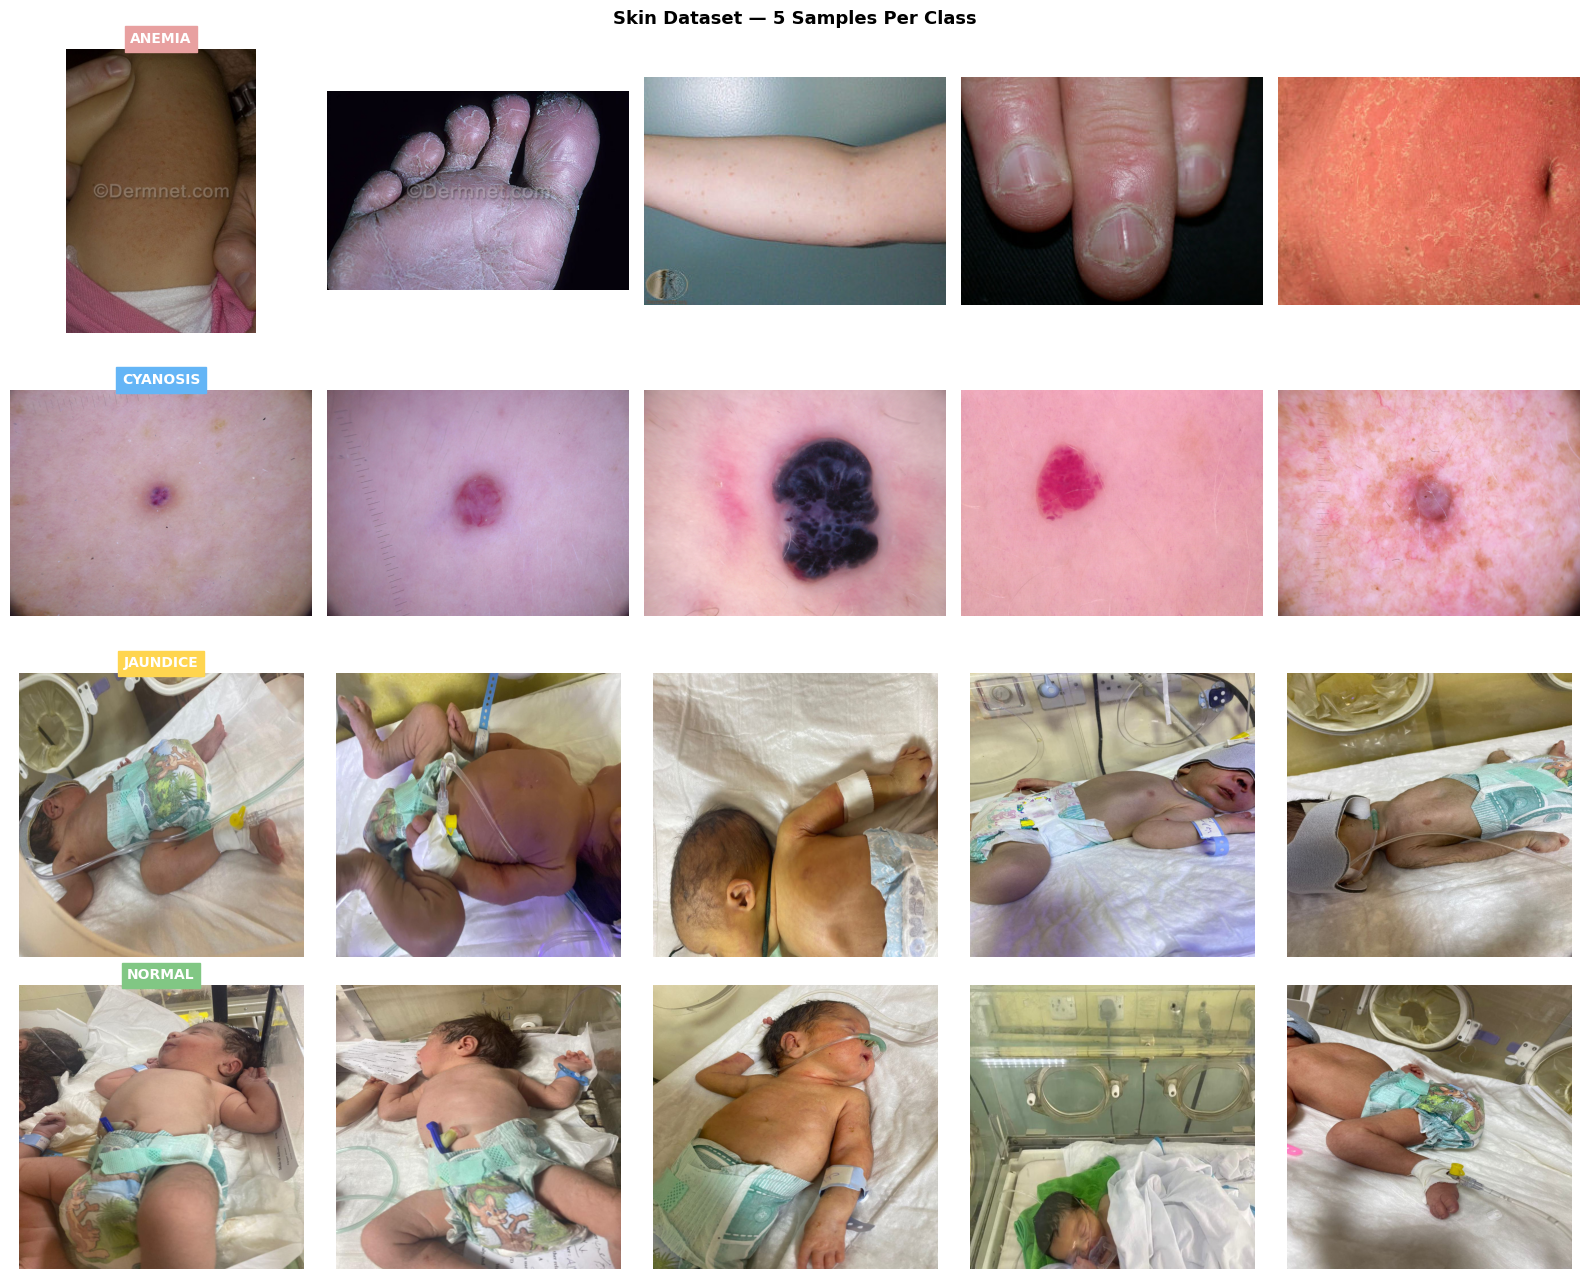

In [8]:
# ── Visualise samples ──
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Skin Dataset — 5 Samples Per Class', fontsize=13, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    imgs = sorted((Path(TRAIN_DIR)/cls).glob('*.jpg'))[:5]
    if not imgs:
        imgs = sorted((Path(TRAIN_DIR)/cls).glob('*.png'))[:5]
    for col, p in enumerate(imgs):
        axes[row][col].imshow(Image.open(p).convert('RGB'))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(
                cls.upper(), fontsize=10, fontweight='bold',
                color='white', backgroundcolor=CLASS_COLORS[cls], pad=4)
plt.tight_layout()
plt.show()

In [9]:
# ── Feature extractor ──
def extract_skin_features(image_path, img_size=128):
    img = cv2.imread(str(image_path))
    if img is None: return None
    img     = cv2.resize(img, (img_size, img_size))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img.astype(float)
    mean_per_channel = img_float.mean(axis=(0, 1))
    overall_mean = mean_per_channel.mean()
    scale = overall_mean / (mean_per_channel + 1e-7)
    img_corrected = np.clip(img_float * scale, 0, 255).astype(np.uint8)

    img_rgb = img_corrected

    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)

    # Per-channel stats
    mean_r, std_r = R.mean(), R.std()
    mean_g, std_g = G.mean(), G.std()
    mean_b, std_b = B.mean(), B.std()

    # Brightness & contrast
    gray       = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(float)
    brightness = gray.mean()
    contrast   = gray.std()

    # Entropy (image complexity)
    hist        = np.histogram(gray, bins=256, range=(0,255))[0]
    img_entropy = scipy_entropy(hist/(hist.sum()+1e-7) + 1e-7)

    # Clinical pixel ratios
    br = brightness + 1e-7
    yellow_ratio = ((R/br > 0.59) & (G/br > 0.47) & (B/br < 0.39)).mean()   # JAUNDICE
    blue_ratio   = ((B > R+20) & (B > G+20)).mean()               # CYANOSIS
    pale_ratio   = ((gray/br > 0.71) & (np.abs(R-G) < 30)).mean()    # ANEMIA

    # HSV features
    hsv      = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(float)
    hue_mean = hsv[:,:,0].mean()
    sat_mean = hsv[:,:,1].mean()
    hue_std  = hsv[:,:,0].std()

    # Derived ratios
    rg_diff  = mean_r - mean_g
    rb_diff  = mean_r - mean_b
    gb_ratio = mean_g / (mean_b + 1e-7)

    return [mean_r, std_r, mean_g, std_g, mean_b, std_b,
            brightness, contrast, img_entropy,
            yellow_ratio, blue_ratio, pale_ratio,
            hue_mean, sat_mean, hue_std,
            rg_diff, rb_diff, gb_ratio]

FEATURE_NAMES = [
    'mean_r','std_r','mean_g','std_g','mean_b','std_b',
    'brightness','contrast','entropy',
    'yellow_ratio','blue_ratio','pale_ratio',
    'hue_mean','sat_mean','hue_std',
    'rg_diff','rb_diff','gb_ratio'
]
print(f'✅ {len(FEATURE_NAMES)} features per image')

✅ 18 features per image


In [10]:
# ── Extract features from all splits ──
def load_split_features(split_dir):
    feats, labels = [], []
    for cls in CLASS_NAMES:
        imgs = list((Path(split_dir)/cls).glob('*.jpg')) + \
               list((Path(split_dir)/cls).glob('*.png'))
        for p in imgs:
            f = extract_skin_features(p)
            if f:
                feats.append(f)
                labels.append(cls)
        print(f'  ✅ {cls:<12} — {len(imgs)} images')
    return pd.DataFrame(feats, columns=FEATURE_NAMES).assign(label=labels)

print('🔄 TRAIN:') ; df_train = load_split_features(TRAIN_DIR)
print('🔄 VAL:')   ; df_val   = load_split_features(VAL_DIR)
print('🔄 TEST:')  ; df_test  = load_split_features(TEST_DIR)
print(f'\n✅ Train:{len(df_train)} | Val:{len(df_val)} | Test:{len(df_test)}')

🔄 TRAIN:
  ✅ anemia       — 698 images
  ✅ cyanosis     — 696 images
  ✅ jaundice     — 700 images
  ✅ normal       — 968 images
🔄 VAL:
  ✅ anemia       — 120 images
  ✅ cyanosis     — 21 images
  ✅ jaundice     — 30 images
  ✅ normal       — 210 images
🔄 TEST:
  ✅ anemia       — 120 images
  ✅ cyanosis     — 22 images
  ✅ jaundice     — 30 images
  ✅ normal       — 210 images

✅ Train:3062 | Val:381 | Test:382


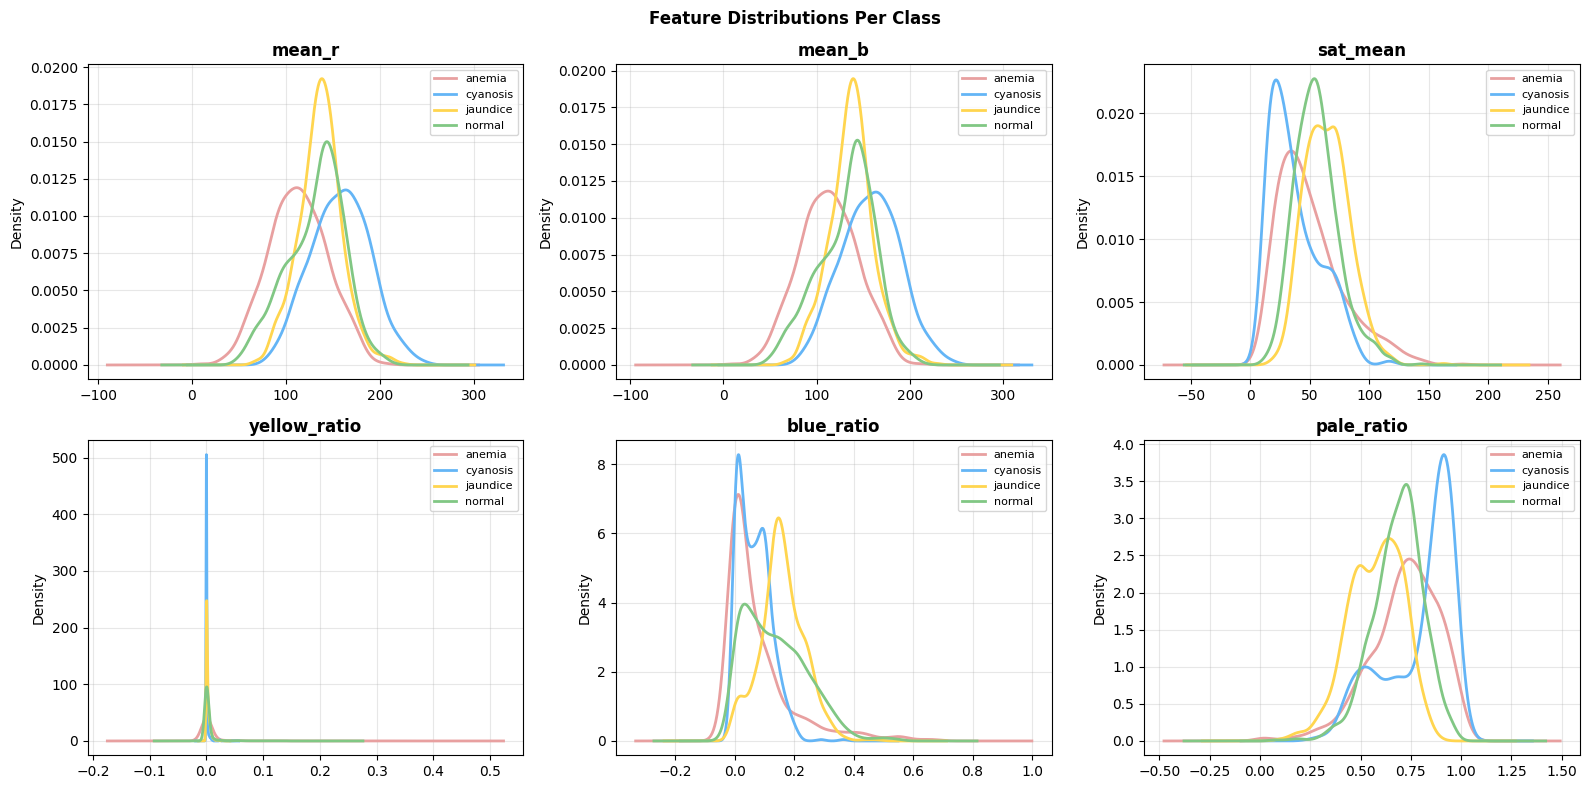

In [11]:
# ── Feature distributions ──
key_feats = ['mean_r','mean_b','sat_mean','yellow_ratio','blue_ratio','pale_ratio']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Feature Distributions Per Class', fontsize=12, fontweight='bold')
for ax, feat in zip(axes.flatten(), key_feats):
    for cls in CLASS_NAMES:
        df_train[df_train['label']==cls][feat].plot.kde(
            ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ── Encode + scale ──
le        = LabelEncoder().fit(CLASS_NAMES)
y_train   = le.transform(df_train['label'])
y_val     = le.transform(df_val['label'])
y_test    = le.transform(df_test['label'])
X_train   = df_train[FEATURE_NAMES].values
X_val     = df_val[FEATURE_NAMES].values
X_test    = df_test[FEATURE_NAMES].values

# Fit ONLY on train — never on val/test (data leakage!)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print('✅ Labels encoded and features scaled')

✅ Labels encoded and features scaled


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

def train_with_cv_final(model, X, y, name, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    val_scores = []
    scaler = StandardScaler()

    print(f"--- {name} (Scaled) ---")
    for fold, (t_idx, v_idx) in enumerate(skf.split(X, y)):
        X_f_train, X_f_val = X[t_idx], X[v_idx]
        y_f_train, y_f_val = y[t_idx], y[v_idx]

        # Scale based only on training fold
        X_f_train_scaled = scaler.fit_transform(X_f_train)
        X_f_val_scaled = scaler.transform(X_f_val)

        model.fit(X_f_train_scaled, y_f_train)
        acc = accuracy_score(y_f_val, model.predict(X_f_val_scaled))
        val_scores.append(acc)
        print(f" Fold {fold+1}: {acc*100:.1f}%")

    avg_val = np.mean(val_scores)

    # Final fit on full training set
    X_train_full_scaled = scaler.fit_transform(X)
    model.fit(X_train_full_scaled, y)

    print(f" Result | Avg Val: {avg_val*100:.1f}%\n")
    return model, scaler

# 1. Train Logistic Regression
lr_m, lr_scaler = train_with_cv_final(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    X_train_s, y_train, "Logistic Regression"
)

# 2. Train Decision Tree
dt_m, dt_scaler = train_with_cv_final(
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    X_train_s, y_train, "Decision Tree"
)

# 3. Train Regularized Random Forest
rf_m, rf_scaler = train_with_cv_final(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    X_train_s, y_train, "Regularized Random Forest"
)

# ── DEFINE VARIABLES FOR PLOTTING ──
# Scale the test set specifically for each model using their respective scalers
X_test_scaled_lr = lr_scaler.transform(X_test_s)
X_test_scaled_dt = dt_scaler.transform(X_test_s)
X_test_scaled_rf = rf_scaler.transform(X_test_s)

# Calculate test accuracies (Fixes the NameError)
lr_test = accuracy_score(y_test, lr_m.predict(X_test_scaled_lr))
dt_test = accuracy_score(y_test, dt_m.predict(X_test_scaled_dt))
rf_test = accuracy_score(y_test, rf_m.predict(X_test_scaled_rf))

print(f"✅ Variables defined for plotting:")
print(f"Logistic Regression Test Acc: {lr_test*100:.1f}%")
print(f"Decision Tree Test Acc:       {dt_test*100:.1f}%")
print(f"Random Forest Test Acc:       {rf_test*100:.1f}%")

--- Logistic Regression (Scaled) ---
 Fold 1: 71.6%
 Fold 2: 73.7%
 Fold 3: 72.9%
 Fold 4: 73.4%
 Fold 5: 72.4%
 Result | Avg Val: 72.8%

--- Decision Tree (Scaled) ---
 Fold 1: 70.1%
 Fold 2: 67.4%
 Fold 3: 70.8%
 Fold 4: 68.5%
 Fold 5: 70.1%
 Result | Avg Val: 69.4%

--- Regularized Random Forest (Scaled) ---
 Fold 1: 75.9%
 Fold 2: 74.6%
 Fold 3: 73.7%
 Fold 4: 73.7%
 Fold 5: 75.0%
 Result | Avg Val: 74.6%

✅ Variables defined for plotting:
Logistic Regression Test Acc: 62.0%
Decision Tree Test Acc:       62.0%
Random Forest Test Acc:       69.9%


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import numpy as np

def evaluate_with_skf(model_class, model_kwargs, X, y, class_names, k=5):
    """
    Full stratified K-fold evaluation.
    Replaces single val-split evaluation for small-class robustness.
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    fold_reports = []
    fold_f1s     = []

    print(f'📊 Stratified {k}-Fold Cross-Validation')
    print('─' * 55)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        # Fit scaler only on training fold — no leakage
        fold_scaler = StandardScaler()
        X_tr_s = fold_scaler.fit_transform(X_tr)
        X_va_s = fold_scaler.transform(X_va)

        clf = model_class(**model_kwargs)
        clf.fit(X_tr_s, y_tr)
        preds = clf.predict(X_va_s)

        f1 = f1_score(y_va, preds, average='macro')
        fold_f1s.append(f1)

        # Show per-class counts so you can see if small classes got covered
        unique, counts = np.unique(y_va, return_counts=True)
        class_dist = {class_names[u]: c for u, c in zip(unique, counts)}
        print(f'  Fold {fold+1}: macro-F1={f1:.4f} | val dist={class_dist}')
        fold_reports.append(classification_report(
            y_va, preds, target_names=class_names, output_dict=True))

    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    print(f'\n  Mean macro-F1: {mean_f1:.4f} ± {std_f1:.4f}')
    print(f'  {"⚠ High variance — model unstable on small classes" if std_f1 > 0.03 else "✅ Stable across folds"}')

    # Per-class average across folds
    print('\n  Per-class F1 (mean across folds):')
    for cls in class_names:
        per_fold = [r[cls]['f1-score'] for r in fold_reports if cls in r]
        print(f'    {cls:<12} {np.mean(per_fold):.4f} ± {np.std(per_fold):.4f}')

    return mean_f1, fold_f1s

# ── Usage: replaces your existing train_with_cv_final calls ─────────
from sklearn.ensemble import RandomForestClassifier

# Combine train+val for a fair cross-validated estimate
X_all = np.vstack([X_train_s, X_val_s])
y_all = np.concatenate([y_train, y_val])

mean_f1, folds = evaluate_with_skf(
    RandomForestClassifier,
    dict(n_estimators=200, max_depth=7, min_samples_leaf=5,
         max_features='sqrt', class_weight='balanced',
         random_state=42, n_jobs=-1),
    X_all, y_all,
    class_names=CLASS_NAMES
)

📊 Stratified 5-Fold Cross-Validation
───────────────────────────────────────────────────────
  Fold 1: macro-F1=0.7422 | val dist={'anemia': np.int64(164), 'cyanosis': np.int64(143), 'jaundice': np.int64(146), 'normal': np.int64(236)}
  Fold 2: macro-F1=0.7381 | val dist={'anemia': np.int64(164), 'cyanosis': np.int64(143), 'jaundice': np.int64(146), 'normal': np.int64(236)}
  Fold 3: macro-F1=0.7539 | val dist={'anemia': np.int64(164), 'cyanosis': np.int64(143), 'jaundice': np.int64(146), 'normal': np.int64(236)}
  Fold 4: macro-F1=0.7334 | val dist={'anemia': np.int64(163), 'cyanosis': np.int64(144), 'jaundice': np.int64(146), 'normal': np.int64(235)}
  Fold 5: macro-F1=0.7363 | val dist={'anemia': np.int64(163), 'cyanosis': np.int64(144), 'jaundice': np.int64(146), 'normal': np.int64(235)}

  Mean macro-F1: 0.7408 ± 0.0071
  ✅ Stable across folds

  Per-class F1 (mean across folds):
    anemia       0.6782 ± 0.0192
    cyanosis     0.8522 ± 0.0185
    jaundice     0.7324 ± 0.0195
   

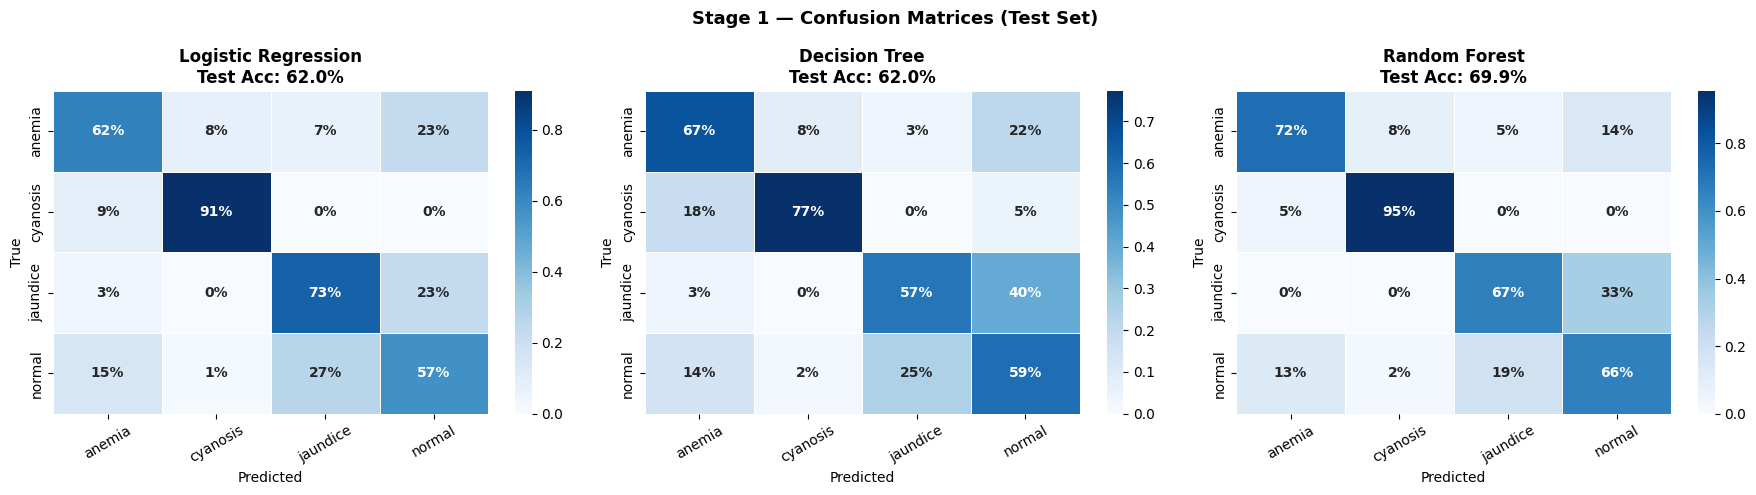

In [15]:
# ── Confusion matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stage 1 — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')
for ax, (name, model, acc) in zip(axes, [
        ('Logistic Regression', lr_m, lr_test),
        ('Decision Tree',       dt_m, dt_test),
        ('Random Forest',       rf_m, rf_test)]):
    # Need to use the scaled test data that each model expects.
    # Since the scalers are fit on the full training data and then transform X_test,
    # the X_test_scaled_lr, X_test_scaled_dt, X_test_scaled_rf should be used accordingly.
    if name == 'Logistic Regression':
        X_test_for_prediction = X_test_scaled_lr
    elif name == 'Decision Tree':
        X_test_for_prediction = X_test_scaled_dt
    else: # Random Forest
        X_test_for_prediction = X_test_scaled_rf

    cm = confusion_matrix(y_test, model.predict(X_test_for_prediction))
    sns.heatmap(cm.astype(float)/cm.sum(axis=1,keepdims=True),
                annot=True, fmt='.0%', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.5, annot_kws={'size':10,'weight':'bold'})
    ax.set_title(f'{name}\nTest Acc: {acc*100:.1f}%', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

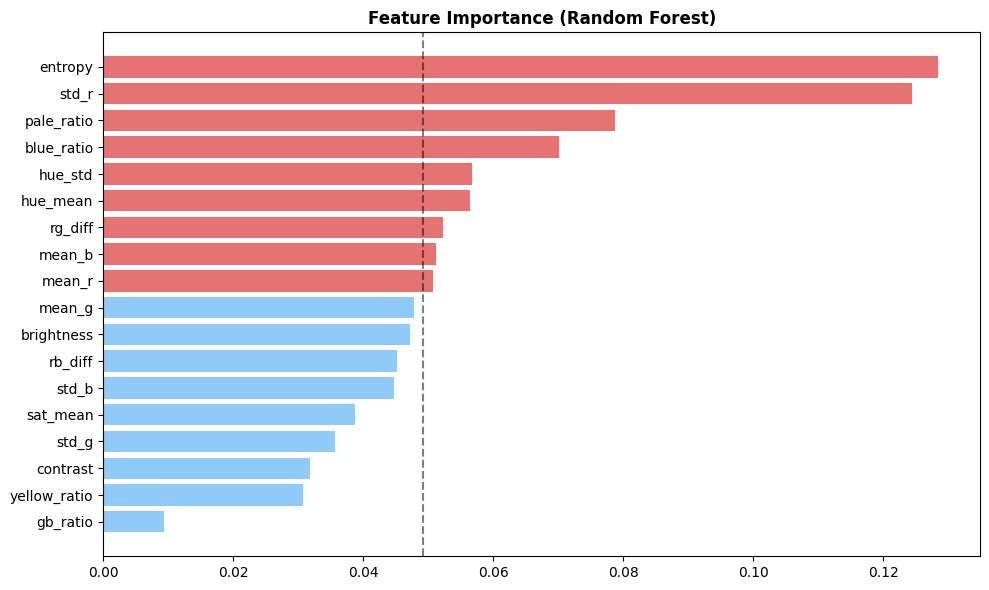


  STAGE 1 RESULTS
  Logistic Regression : 62.0%
  Decision Tree       : 62.0%
  Random Forest       : 69.9%
  18 colour features capture WHAT colour the skin is
  but NOT the spatial arrangement of those colours.
  → Stage 2: give the model ALL pixels instead



In [16]:
# ── Feature importance + Stage 1 summary ──
importances = pd.Series(rf_m.feature_importances_, index=FEATURE_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances.index, importances.values,
        color=['#E57373' if v > importances.median() else '#90CAF9'
               for v in importances])
ax.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax.axvline(importances.median(), color='black', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"""
{'='*55}
  STAGE 1 RESULTS
{'='*55}
  Logistic Regression : {lr_test*100:.1f}%
  Decision Tree       : {dt_test*100:.1f}%
  Random Forest       : {rf_test*100:.1f}%
{'='*55}
  18 colour features capture WHAT colour the skin is
  but NOT the spatial arrangement of those colours.
  → Stage 2: give the model ALL pixels instead
""")

In [17]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
print('✅ Stage 2 imports ready')

✅ Stage 2 imports ready


In [18]:
# ── Load and flatten images ──
S2_SIZE = 64   # 64x64x3 = 12,288 features per image

def load_flat_pixels(split_dir, img_size=S2_SIZE):
    X, y = [], []
    for cls in CLASS_NAMES:
        imgs = list((Path(split_dir)/cls).glob('*.jpg')) + \
               list((Path(split_dir)/cls).glob('*.png'))
        for p in imgs:
            img = cv2.imread(str(p))
            if img is None: continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img.flatten() / 255.0)
            y.append(cls)
        print(f'  ✅ {cls:<12} — {len(imgs)} images')
    return np.array(X), np.array(y)

print(f'🔄 Loading flat pixels at {S2_SIZE}x{S2_SIZE}...')
print('TRAIN:'); X2_train, y2_train_str = load_flat_pixels(TRAIN_DIR)
print('VAL:');   X2_val,   y2_val_str   = load_flat_pixels(VAL_DIR)
print('TEST:');  X2_test,  y2_test_str  = load_flat_pixels(TEST_DIR)

y2_train = le.transform(y2_train_str)
y2_val   = le.transform(y2_val_str)
y2_test  = le.transform(y2_test_str)

print(f'\n📐 Each image = {X2_train.shape[1]:,} numbers')
print(f'   Stage 1 used only {len(FEATURE_NAMES)} features')
print(f'   Now we have {X2_train.shape[1]:,} — {X2_train.shape[1]//len(FEATURE_NAMES)}x more')

🔄 Loading flat pixels at 64x64...
TRAIN:
  ✅ anemia       — 698 images
  ✅ cyanosis     — 696 images
  ✅ jaundice     — 700 images
  ✅ normal       — 968 images
VAL:
  ✅ anemia       — 120 images
  ✅ cyanosis     — 21 images
  ✅ jaundice     — 30 images
  ✅ normal       — 210 images
TEST:
  ✅ anemia       — 120 images
  ✅ cyanosis     — 22 images
  ✅ jaundice     — 30 images
  ✅ normal       — 210 images

📐 Each image = 12,288 numbers
   Stage 1 used only 18 features
   Now we have 12,288 — 682x more


🔄 PCA: 12,288 → 200 components...
✅ 200 components explain 88.2% of variance


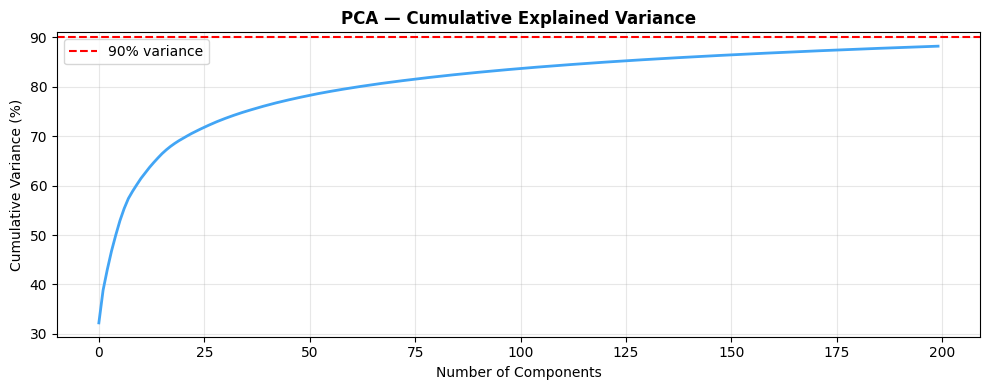

In [19]:
# ── PCA: reduce dimensionality before SVM ──
N_COMPONENTS = 200
print(f'🔄 PCA: {X2_train.shape[1]:,} → {N_COMPONENTS} components...')

pca          = PCA(n_components=N_COMPONENTS, random_state=42)
X2_train_pca = pca.fit_transform(X2_train)
X2_val_pca   = pca.transform(X2_val)
X2_test_pca  = pca.transform(X2_test)
var_explained = pca.explained_variance_ratio_.sum()
print(f'✅ {N_COMPONENTS} components explain {var_explained*100:.1f}% of variance')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_)*100, color='#42A5F5', linewidth=2)
ax.axhline(90, color='red', ls='--', label='90% variance')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance (%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ── Train SVM ──
print('🔄 Training SVM...')
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X2_train_pca, y2_train)
svm_val  = accuracy_score(y2_val,  svm.predict(X2_val_pca))
svm_test = accuracy_score(y2_test, svm.predict(X2_test_pca))
print(f'✅ SVM | Val:{svm_val*100:.1f}%  Test:{svm_test*100:.1f}%')

🔄 Training SVM...
✅ SVM | Val:87.1%  Test:89.5%


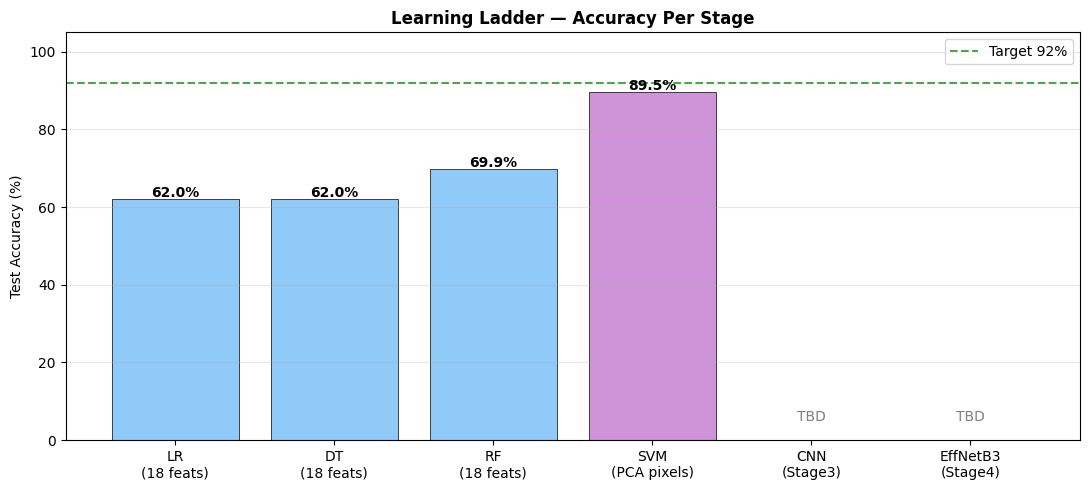


  STAGE 2 KEY LESSON — Curse of Dimensionality
  Stage 1 Random Forest (18 features) : 69.9%
  Stage 2 SVM (12,288 pixel features) : 89.5%
  Difference                          : +19.6%

  More features gave almost NO improvement!
  Because pixels have NO spatial awareness.
  SVM sees pixel[50,50] and pixel[51,50] as
  completely unrelated — even though neighbours.

  → Stage 3: CNN understands spatial relationships



In [21]:
# ── Stage 1 vs Stage 2 bar chart ──
fig, ax = plt.subplots(figsize=(11, 5))
labels_bar = ['LR\n(18 feats)','DT\n(18 feats)','RF\n(18 feats)',
               'SVM\n(PCA pixels)','CNN\n(Stage3)','EffNetB3\n(Stage4)']
values     = [lr_test*100, dt_test*100, rf_test*100, svm_test*100, 0, 0]
colors_bar = ['#90CAF9','#90CAF9','#90CAF9','#CE93D8','#A5D6A7','#EF9A9A']
bars = ax.bar(labels_bar, values, color=colors_bar, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, values):
    if v > 0:
        ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    else:
        ax.text(bar.get_x()+bar.get_width()/2, 5,
                'TBD', ha='center', fontsize=10, color='gray')
ax.axhline(92, color='green', ls='--', alpha=0.7, label='Target 92%')
ax.set_ylim(0, 105)
ax.set_title('Learning Ladder — Accuracy Per Stage', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
{'='*55}
  STAGE 2 KEY LESSON — Curse of Dimensionality
{'='*55}
  Stage 1 Random Forest (18 features) : {rf_test*100:.1f}%
  Stage 2 SVM (12,288 pixel features) : {svm_test*100:.1f}%
  Difference                          : {(svm_test-rf_test)*100:+.1f}%

  More features gave almost NO improvement!
  Because pixels have NO spatial awareness.
  SVM sees pixel[50,50] and pixel[51,50] as
  completely unrelated — even though neighbours.

  → Stage 3: CNN understands spatial relationships
""")

In [22]:
# ── DataLoaders for Stage 3 (64x64) with Targeted Augmentation ──
S3_SIZE = 64

In [23]:
class JaundiceTargetedAug:
    def __call__(self, img):
        if np.random.rand() > 0.3:
            img_np = np.array(img).astype(float)
            img_np[:, :, 0] *= np.random.uniform(1.15, 1.35)
            img_np[:, :, 1] *= np.random.uniform(1.05, 1.15)
            img_np[:, :, 2] *= np.random.uniform(0.6, 0.85)
            return Image.fromarray(np.clip(img_np, 0, 255).astype(np.uint8))
        return img

class CyanosisTargetedAug:
    def __call__(self, img):
        if np.random.rand() > 0.4:
            img_np = np.array(img).astype(float)
            img_np[:, :, 0] *= np.random.uniform(0.6, 0.85)
            img_np[:, :, 1] *= np.random.uniform(0.7, 0.9)
            img_np[:, :, 2] *= np.random.uniform(1.1, 1.35)
            return Image.fromarray(np.clip(img_np, 0, 255).astype(np.uint8))
        return img

class AnemiaTargetedAug:
    def __call__(self, img):
        if np.random.rand() > 0.4:
            img_np = np.array(img).astype(float)
            img_np[:, :, 0] *= np.random.uniform(0.75, 0.92)
            img_np[:, :, 1] *= np.random.uniform(0.75, 0.92)
            img_np[:, :, 2] *= np.random.uniform(0.75, 0.92)
            return Image.fromarray(np.clip(img_np, 0, 255).astype(np.uint8))
        return img

class CLAHETransform:
    def __init__(self, clip_limit=3.0, tile=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    def __call__(self, img):
        arr = np.array(img.convert('RGB'))
        lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
        lab[:,:,0] = self.clahe.apply(lab[:,:,0])
        return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

class ClassAwareDataset(torch.utils.data.Dataset):
    """
    Applies different augmentations per class.
    Jaundice/Cyanosis/Anemia get color-targeted augmentation.
    Normal gets standard augmentation only.
    """
    def __init__(self, root_dir, transform_map, base_transform):
        self.dataset = ImageFolder(root_dir)
        self.transform_map = transform_map
        self.base_transform = base_transform
        self.idx_to_class = {v: k for k, v in self.dataset.class_to_idx.items()}

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.dataset.samples[idx]
        cls_name = self.idx_to_class[label]
        img = Image.open(path).convert('RGB')

        if cls_name in self.transform_map:
            img = self.transform_map[cls_name](img)

        img = self.base_transform(img);
        return img, label

    @property
    def targets(self):
        return [s[1] for s in self.dataset.samples]

    @property
    def class_to_idx(self):
        return self.dataset.class_to_idx

    @property
    def samples(self):
        return self.dataset.samples


# Base transform for all classes
base_train_transform = transforms.Compose([
    transforms.Resize((S3_SIZE + 32, S3_SIZE + 32)), # Use S3_SIZE instead of IMG_SIZE
    CLAHETransform(),
    transforms.RandomCrop(S3_SIZE), # Use S3_SIZE instead of IMG_SIZE
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((S3_SIZE, S3_SIZE)), # Use S3_SIZE instead of IMG_SIZE
    CLAHETransform(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Class specific color augmentations
transform_map = {
    'jaundice': JaundiceTargetedAug(),
    'cyanosis': CyanosisTargetedAug(),
    'anemia':   AnemiaTargetedAug(),
}

train_dataset = ClassAwareDataset(TRAIN_DIR, transform_map, base_train_transform)
val_dataset   = ImageFolder(VAL_DIR,  transform=val_transform)
test_dataset  = ImageFolder(TEST_DIR, transform=val_transform)

print(f'✅ Train:{len(train_dataset)} Val:{len(val_dataset)} Test:{len(test_dataset)}')
print(f'Classes: {train_dataset.class_to_idx}')

✅ Train:3062 Val:381 Test:382
Classes: {'anemia': 0, 'cyanosis': 1, 'jaundice': 2, 'normal': 3}


In [24]:
# ── Focal Loss + Class Weights ──
import torch.nn.functional as F
from collections import Counter

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt    = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()


def compute_class_weights(dataset, class_names, device):
    counts    = Counter(dataset.targets)
    n_total   = sum(counts.values())
    n_classes = len(class_names)
    raw = np.array([
        n_total / (counts[dataset.class_to_idx[c]] + 1e-7)
        for c in class_names
    ])
    raw     = np.sqrt(raw)
    weights = (raw / raw.sum()) * n_classes
    print('Class weights:')
    for c, w in zip(class_names, weights):
        print(f'  {c:<12} {w:.4f}')
    return torch.tensor(weights, dtype=torch.float).to(device)


class_weights = compute_class_weights(train_dataset, CLASS_NAMES, device)
criterion     = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.1)
print('✅ Focal Loss ready')

Class weights:
  anemia       1.0392
  cyanosis     1.0407
  jaundice     1.0377
  normal       0.8824
✅ Focal Loss ready


In [25]:
# ── Simple 3-layer CNN ──
#
# Architecture:
#   Input 3x64x64
#   → Conv(3→32) + BN + ReLU + MaxPool  →  32x32x32
#   → Conv(32→64) + BN + ReLU + MaxPool →  64x16x16
#   → Conv(64→128) + BN + ReLU + MaxPool → 128x8x8
#   → Flatten → 8192
#   → Linear(8192→256) → ReLU
#   → Linear(256→4)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — detects basic colour patches and edges
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 64 → 32

            # Block 2 — detects combinations of edges (shapes)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32 → 16

            # Block 3 — detects higher-level patterns
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16 → 8
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

s3_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
total    = sum(p.numel() for p in s3_model.parameters())
print(f'✅ SimpleCNN — {total:,} parameters')

✅ SimpleCNN — 2,192,132 parameters


In [31]:
# ── Training loop ──
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    loss_sum, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training:
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
    return loss_sum/total, correct/total

# ── Stage 3 DataLoaders — defined here directly ───────────────
S3_SIZE = 64

s3_train_transform = transforms.Compose([
    transforms.Resize((S3_SIZE, S3_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

s3_val_transform = transforms.Compose([
    transforms.Resize((S3_SIZE, S3_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

s3_train_dataset = ImageFolder(TRAIN_DIR, transform=s3_train_transform)
s3_val_dataset   = ImageFolder(VAL_DIR,   transform=s3_val_transform)
s3_test_dataset  = ImageFolder(TEST_DIR,  transform=s3_val_transform)

# ── Sampler ───────────────────────────────────────────────────
s3_targets  = [s[1] for s in s3_train_dataset.samples]
s3_cls_cnt  = np.bincount(s3_targets)
s3_weights  = [1.0 / s3_cls_cnt[t] for t in s3_targets]
s3_sampler  = WeightedRandomSampler(s3_weights, len(s3_weights), replacement=True)

s3_train_loader = DataLoader(s3_train_dataset, batch_size=BATCH_SIZE,
                              sampler=s3_sampler, num_workers=0, pin_memory=False)
s3_val_loader   = DataLoader(s3_val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False,    num_workers=0, pin_memory=False)
s3_test_loader  = DataLoader(s3_test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False,    num_workers=0, pin_memory=False)

print(f'✅ Stage 3 DataLoaders ready!')
print(f'   Train: {len(s3_train_dataset)} | Val: {len(s3_val_dataset)} | Test: {len(s3_test_dataset)}')

# ── Stage 3 Training Config ───────────────────────────────────
s3_criterion  = criterion
s3_optimizer  = optim.Adam(s3_model.parameters(), lr=1e-3, weight_decay=1e-4)
s3_scheduler  = CosineAnnealingLR(s3_optimizer, T_max=30, eta_min=1e-5)
S3_EPOCHS     = 30
S3_PATIENCE   = 7
s3_history    = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
s3_best_acc   = 0.0
s3_no_improve = 0
S3_CKPT       = os.path.join(OUT_DIR, 'checkpoints', 'stage3_simplecnn.pth')

print(f'🚀 Training SimpleCNN — {S3_EPOCHS} epochs')
print('='*60)
for epoch in range(1, S3_EPOCHS+1):
    t_loss, t_acc = run_epoch(s3_model, s3_train_loader, s3_criterion, s3_optimizer)
    v_loss, v_acc = run_epoch(s3_model, s3_val_loader,   s3_criterion)
    s3_scheduler.step()
    for k,v in zip(['train_loss','train_acc','val_loss','val_acc'],
                   [t_loss,t_acc,v_loss,v_acc]):
        s3_history[k].append(v)
    tag = ''
    if v_acc > s3_best_acc:
        s3_best_acc = v_acc; s3_no_improve = 0
        torch.save(s3_model.state_dict(), S3_CKPT); tag = ' ✅'
    else:
        s3_no_improve += 1
    if epoch % 5 == 0 or tag:
        print(f'Ep {epoch:03d} | T={t_acc:.3f} V={v_acc:.3f}{tag}')
    if s3_no_improve >= S3_PATIENCE:
        print(f'⏹ Early stop at epoch {epoch}'); break
print('='*60)
print(f'🏆 Best Val Acc: {s3_best_acc*100:.2f}%')

✅ Stage 3 DataLoaders ready!
   Train: 3062 | Val: 381 | Test: 382
🚀 Training SimpleCNN — 30 epochs
Ep 001 | T=0.888 V=0.864 ✅
Ep 003 | T=0.912 V=0.887 ✅
Ep 005 | T=0.931 V=0.850
Ep 007 | T=0.932 V=0.898 ✅
Ep 010 | T=0.935 V=0.890
Ep 011 | T=0.957 V=0.906 ✅
Ep 012 | T=0.951 V=0.916 ✅
Ep 013 | T=0.954 V=0.919 ✅
Ep 015 | T=0.961 V=0.895
Ep 018 | T=0.970 V=0.924 ✅
Ep 020 | T=0.975 V=0.927 ✅
Ep 021 | T=0.972 V=0.929 ✅
Ep 023 | T=0.978 V=0.937 ✅
Ep 025 | T=0.975 V=0.929
Ep 028 | T=0.982 V=0.940 ✅
Ep 030 | T=0.981 V=0.937
🏆 Best Val Acc: 93.96%


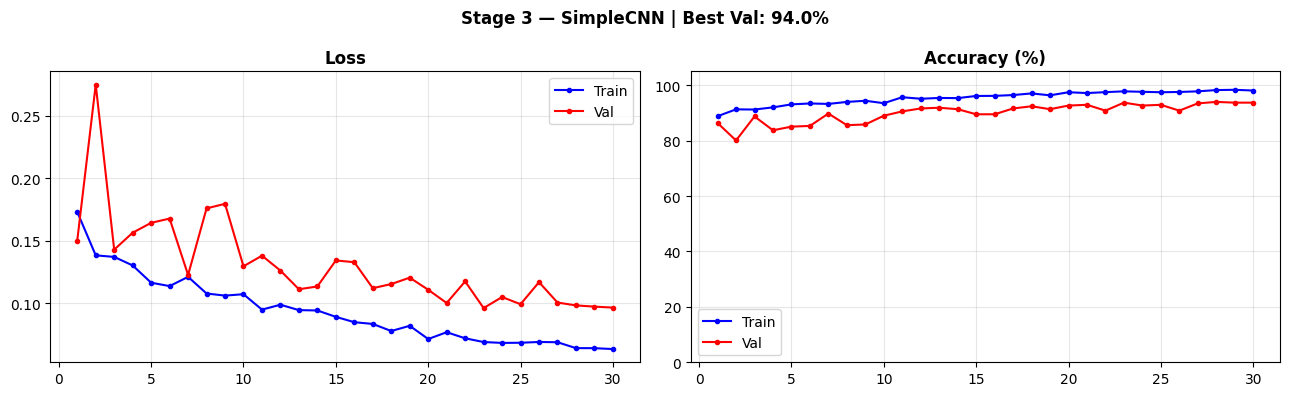


✅ Stage 3 Test Accuracy: 94.76%
              precision    recall  f1-score   support

      anemia      1.000     0.975     0.987       120
    cyanosis      0.917     1.000     0.957        22
    jaundice      0.651     0.933     0.767        30
      normal      0.985     0.929     0.956       210

    accuracy                          0.948       382
   macro avg      0.888     0.959     0.917       382
weighted avg      0.959     0.948     0.951       382



In [32]:
# ── Training curves + test evaluation ──
ep = range(1, len(s3_history['train_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep, s3_history['train_loss'], 'b-o', ms=3, label='Train')
ax1.plot(ep, s3_history['val_loss'],   'r-o', ms=3, label='Val')
ax1.set_title('Loss', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, [a*100 for a in s3_history['train_acc']], 'b-o', ms=3, label='Train')
ax2.plot(ep, [a*100 for a in s3_history['val_acc']],   'r-o', ms=3, label='Val')
ax2.set_title('Accuracy (%)', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 105)
fig.suptitle(f'Stage 3 — SimpleCNN | Best Val: {s3_best_acc*100:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Test accuracy
s3_model.load_state_dict(torch.load(S3_CKPT))
s3_model.eval()
all_preds, all_labels_s3 = [], []
with torch.no_grad():
    for imgs, labels in s3_test_loader:
        preds = s3_model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels_s3.extend(labels.numpy())
s3_test = accuracy_score(all_labels_s3, all_preds)
print(f'\n✅ Stage 3 Test Accuracy: {s3_test*100:.2f}%')
print(classification_report(all_labels_s3, all_preds,
                             target_names=CLASS_NAMES, digits=3))

In [38]:
# ── DataLoaders with CLAHE at 224x224 ──
class CLAHETransform:
    """Apply CLAHE — creates instance inside __call__ to avoid pickle error on Windows."""
    def __init__(self, clip_limit=2.0, tile=(8,8)):
        self.clip_limit = clip_limit   # store params only
        self.tile       = tile         # NOT the cv2 object

    def __call__(self, img):
        clahe = cv2.createCLAHE(         # create fresh each call
            clipLimit    = self.clip_limit,
            tileGridSize = self.tile
        )
        arr = np.array(img.convert('RGB'))
        lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
    CLAHETransform(),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    CLAHETransform(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = ImageFolder(VAL_DIR,   transform=val_transform)
test_dataset  = ImageFolder(TEST_DIR,  transform=val_transform)

targets  = [s[1] for s in train_dataset.samples]
cls_cnt  = np.bincount(targets)
sample_w = [1.0/cls_cnt[t] for t in targets]
sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
print(f'✅ Train:{len(train_dataset)} | Val:{len(val_dataset)} | Test:{len(test_dataset)}')

✅ Train:3062 | Val:381 | Test:382


In [39]:
# ── Boosted Sampler for Jaundice + Cyanosis ──

targets  = train_dataset.targets
cls_cnt  = np.bincount(targets)
n_total  = len(targets)

sample_weights = np.array([
    n_total / (cls_cnt[t] * len(cls_cnt))
    for t in targets
])

jaundice_idx = train_dataset.class_to_idx['jaundice']
cyanosis_idx = train_dataset.class_to_idx['cyanosis']

for i, t in enumerate(targets):
    if t == jaundice_idx:
        sample_weights[i] *= 2.5
    elif t == cyanosis_idx:
        sample_weights[i] *= 2.0

sampler = WeightedRandomSampler(
    weights     = sample_weights.tolist(),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print('✅ Boosted DataLoaders ready')
print(f'  Jaundice boost: 2.5x  |  Cyanosis boost: 2.0x')

✅ Boosted DataLoaders ready
  Jaundice boost: 2.5x  |  Cyanosis boost: 2.0x


In [40]:
# ── Stage 4: Advanced EfficientNetB3 with Gradual Unfreezing ──
class NeoScanSkinModel(nn.Module):
    def __init__(self, num_classes=4, freeze_ratio=0.7): # Slightly less freezing to start
        super().__init__()
        # Load weights
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features

        # Initial Freeze: Freeze only the first 70% of layers
        layers = list(self.features.children())
        freeze_until = int(len(layers) * freeze_ratio)
        for i, layer in enumerate(layers):
            if i < freeze_until:
                for p in layer.parameters(): p.requires_grad = False

        self.avgpool = backbone.avgpool
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(backbone.classifier[1].in_features, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def unfreeze_all(self):
        """Call this mid-training to allow deep fine-tuning"""
        for param in self.parameters():
            param.requires_grad = True
        print("🔓 Backbone fully unfrozen for fine-tuning.")

    def gradcam_target_layer(self):
        # Return the last convolutional layer for GradCAM
        # For EfficientNetB3, this is typically the last block of the features extractor
        return self.features[-1]

# Initialize model (re-initialize after adding gradcam_target_layer)
model_s4 = NeoScanSkinModel().to(device)
optimizer = optim.Adam(model_s4.parameters(), lr=1e-4) # Start with standard LR

# --- Inside your Training Loop ---
# Add this logic to your existing loop:
# for epoch in range(num_epochs):
#     if epoch == 10: # After 10 epochs of training the top layers
#         model_s4.unfreeze_all()
#         # Reduce learning rate for fine-tuning to avoid destroying pre-trained weights
#         optimizer = optim.Adam(model_s4.parameters(), lr=1e-5)
print('✅ NeoScanSkinModel ready')

✅ NeoScanSkinModel ready


In [41]:
# ── train_epoch and evaluate for Stage 4 ──
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out   = model(imgs)
            probs = torch.softmax(out, dim=1)
            loss_sum += criterion(out, labels).item() * imgs.size(0)
            correct  += (probs.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (loss_sum / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print('✅ train_epoch and evaluate defined')

✅ train_epoch and evaluate defined


In [ ]:
# ── Retrain Stage 4 EfficientNetB3 with all fixes ──

EPOCHS     = 80
PATIENCE   = 15
best_acc   = 0.0
no_improve = 0
CKPT       = os.path.join(OUT_DIR, 'checkpoints', 'best_model.pth')
history    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}  # ← ADDED

backbone_params = [p for n, p in model_s4.named_parameters()
                   if p.requires_grad and 'classifier' not in n]
head_params     = list(model_s4.classifier.parameters())

optimizer = optim.Adam([
    {'params': backbone_params, 'lr': LR * 0.05},
    {'params': head_params,     'lr': LR},
], weight_decay=2e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print('🚀 Retraining EfficientNetB3 with Focal Loss + Class-Aware Augmentation')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):

    # Unfreeze full backbone at epoch 15
    if epoch == 15:
        for p in model_s4.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(
            model_s4.parameters(),
            lr=1e-5, weight_decay=2e-4
        )
        print('🔓 Full backbone unfrozen at epoch 15')

    t_loss, t_acc                     = train_epoch(model_s4, train_loader, criterion, optimizer, device)
    v_loss, v_acc, v_preds, v_lbls, _ = evaluate(model_s4, val_loader, criterion, device)
    v_f1 = f1_score(v_lbls, v_preds, average='macro')
    scheduler.step()

    # ── ADDED: populate history ──
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    tag = ''
    if v_acc > best_acc:
        best_acc   = v_acc
        no_improve = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model_s4.state_dict(),
            'val_acc':          v_acc,
            'val_f1':           v_f1,
            'class_to_idx':     train_dataset.class_to_idx
        }, CKPT)
        tag = ' ✅'
    else:
        no_improve += 1

    print(f'Ep {epoch:03d} | T={t_acc:.4f} V={v_acc:.4f} F1={v_f1:.4f}{tag}')

    if no_improve >= PATIENCE:
        print(f'⏹ Early stop at epoch {epoch}')
        break

print(f'\n🏆 Best Val Acc: {best_acc*100:.2f}%')

In [ ]:
# ── Training curves ──
ep = range(1, len(history['train_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, history['train_loss'], 'b-o', ms=3, label='Train')
ax1.plot(ep, history['val_loss'],   'r-o', ms=3, label='Val')
ax1.set_title('Loss', fontweight='bold'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, [a*100 for a in history['train_acc']], 'b-o', ms=3, label='Train')
ax2.plot(ep, [a*100 for a in history['val_acc']],   'r-o', ms=3, label='Val')
ax2.axhline(93, color='green', ls='--', alpha=0.6, label='Target 93%')
best_ep = np.argmax(history['val_acc'])+1
ax2.axvline(best_ep, color='orange', ls='--', alpha=0.7, label=f'Best@E{best_ep}')
ax2.set_title('Accuracy (%)', fontweight='bold')
ax2.set_ylim(0, 105); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle(f'Stage 4 — EfficientNetB3 | Best Val: {best_acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/plots/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Test set evaluation ──
ckpt = torch.load(CKPT, map_location=device)
model_s4.load_state_dict(ckpt['model_state_dict'])
print(f'✅ Loaded best model (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.4f})')

_, test_acc, test_preds, test_labels, test_probs = evaluate(
    model_s4, test_loader, criterion, device)
idx_to_class = {v:k for k,v in test_dataset.class_to_idx.items()}
classes_ord  = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'\n{"="*55}')
print(f'  TEST ACCURACY : {test_acc*100:.2f}%')
print(f'{"="*55}')
print(classification_report(test_labels, test_preds,
                             target_names=classes_ord, digits=4))
lb  = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))
auc = roc_auc_score(lb, test_probs, multi_class='ovr', average='macro')
print(f'  AUC-ROC (macro): {auc:.4f}')
print(f'  F1  (macro)    : {f1_score(test_labels, test_preds, average="macro"):.4f}')

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
        axes,
        [cm, cm.astype(float)/cm.sum(axis=1, keepdims=True)],
        ['d', '.2%'],
        ['Counts', 'Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=classes_ord, yticklabels=classes_ord,
                ax=ax, linewidths=0.5, annot_kws={'size':11,'weight':'bold'})
    ax.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('NeoScan Skin — Stage 4 Test Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def denorm(t):
    t = t.clone().cpu()
    for c, m, s in zip(range(3), MEAN, STD):
        t[c] = t[c]*s + m
    return np.clip(t.permute(1,2,0).numpy(), 0, 1)

def get_cam(model, tensor, pred_idx, device):
    cam  = GradCAM(model=model, target_layers=[model.gradcam_target_layer()])
    mask = cam(input_tensor=tensor.unsqueeze(0).to(device),
               targets=[ClassifierOutputTarget(pred_idx)])
    return mask[0]

# Collect 3 samples per class
samples_per_cls = {c:[] for c in CLASS_NAMES}
for path, label in test_dataset.samples:
    cls = idx_to_class[label]
    if len(samples_per_cls[cls]) < 3:
        samples_per_cls[cls].append((path, label))

# GradCAM grid
model_s4.eval()
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(18, NUM_CLASSES*3))
fig.suptitle('GradCAM — Skin Regions Driving Each Prediction\n'
             'Red=high influence | Blue=low influence',
             fontsize=13, fontweight='bold')
for row, cls in enumerate(CLASS_NAMES):
    for col, (img_path, true_lbl) in enumerate(samples_per_cls[cls]):
        tensor   = val_transform(Image.open(img_path).convert('RGB'))
        with torch.no_grad():
            pred = model_s4(tensor.unsqueeze(0).to(device)).argmax(1).item()
        cam_mask = get_cam(model_s4, tensor, pred, device)
        img_np   = denorm(tensor)
        cam_img  = show_cam_on_image(img_np, cam_mask, use_rgb=True)
        ax_o = axes[row][col*2];   ax_c = axes[row][col*2+1]
        ax_o.imshow(img_np);       ax_o.axis('off')
        if col == 0:
            ax_o.set_ylabel(cls.upper(), fontsize=9, fontweight='bold',
                            color='white', rotation=90,
                            bbox=dict(facecolor=CLASS_COLORS[cls], pad=2))
        ax_c.imshow(cam_img)
        ax_c.set_title(f'→ {idx_to_class[pred]}', fontsize=8,
                       color='lime' if pred==true_lbl else 'red',
                       fontweight='bold')
        ax_c.axis('off')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/gradcam/gradcam_grid.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ── Clinical prediction function ──
CLINICAL_ACTIONS = {
    'jaundice' : '⚠️  Check bilirubin. Consider phototherapy if >15 mg/dL.',
    'cyanosis' : '🚨 URGENT: Check O₂ saturation. May indicate cardiac/respiratory issue.',
    'anemia'   : '⚠️  Obtain CBC. Check haemoglobin. Assess for haemolysis.',
    'normal'   : '✅ Skin tone normal. Routine monitoring recommended.',
}
SEVERITY = {'jaundice':'MODERATE','cyanosis':'CRITICAL','anemia':'MODERATE','normal':'NONE'}

def predict_skin(image_path, model, device):
    model.eval()
    pil_img = Image.open(image_path).convert('RGB')
    tensor  = val_transform(pil_img)
    img_np  = denorm(tensor)
    with torch.no_grad():
        probs = torch.softmax(
            model(tensor.unsqueeze(0).to(device)), dim=1
        ).squeeze().cpu().numpy()
    pred       = int(probs.argmax())
    pred_class = idx_to_class[pred]
    conf       = float(probs[pred])
    class_list = [idx_to_class[i] for i in range(NUM_CLASSES)]
    cam_mask   = get_cam(model, tensor, pred, device)
    cam_img    = show_cam_on_image(img_np, cam_mask, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.patch.set_facecolor('#111827')
    axes[0].imshow(pil_img); axes[0].axis('off')
    axes[0].set_title('Input Image', color='white', fontweight='bold')
    axes[1].imshow(cam_img); axes[1].axis('off')
    axes[1].set_title('GradCAM\n(red=high influence)', color='white', fontweight='bold')
    bars = axes[2].barh(class_list, probs*100,
                        color=[CLASS_COLORS[c] for c in class_list],
                        edgecolor='white', linewidth=0.5)
    axes[2].set_xlim(0, 115); axes[2].set_facecolor('#111827')
    axes[2].tick_params(colors='white')
    axes[2].set_xlabel('Confidence %', color='white')
    axes[2].set_title('Class Probabilities', color='white', fontweight='bold')
    for spine in axes[2].spines.values(): spine.set_edgecolor('#333')
    for bar, p in zip(bars, probs):
        axes[2].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', color='white', fontsize=10)
    bars[pred].set_linewidth(3)
    sev_col = {'CRITICAL':'#FF4444','MODERATE':'#FFA500','NONE':'#44DD44'}[SEVERITY[pred_class]]
    fig.suptitle(
        f'NeoScan AI — Skin Analysis\n'
        f'Prediction: {pred_class.upper()} | Confidence: {conf*100:.1f}% | '
        f'Severity: {SEVERITY[pred_class]}',
        color=sev_col, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/gradcam/report_{pred_class}.png',
                dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print(f"\n{'='*52}")
    print(f" 🏥 NeoScan AI — CLINICAL REPORT")
    print(f"{'='*52}")
    print(f" Condition  : {pred_class.upper()}")
    print(f" Confidence : {conf*100:.2f}%")
    print(f" Severity   : {SEVERITY[pred_class]}")
    print(f" Action     : {CLINICAL_ACTIONS[pred_class]}")
    print(f"{'─'*52}")
    for c, p in sorted(zip(class_list, probs), key=lambda x: -x[1]):
        print(f" {c:<10} {'█'*int(p*28):<28} {p*100:.1f}%")
    print(f"{'='*52}")
    print(" ⚠️  AI tool only — physician confirmation required.")
    print(f"{'='*52}")

# Run demo on one image per class
for cls in CLASS_NAMES:
    print(f'\n── Demo: {cls} ──')
    predict_skin(samples_per_cls[cls][0][0], model_s4, device)


In [ ]:
# ── Model saved locally ──────────────────────────────────────
import shutil

ckpt_path  = os.path.join(OUT_DIR, 'checkpoints', 'best_model.pth')
local_copy = os.path.join(BASE_DIR, 'best_model.pth')

if os.path.exists(ckpt_path):
    shutil.copy2(ckpt_path, local_copy)
    size_mb = os.path.getsize(local_copy) / (1024*1024)
    print(f"✅ Model saved to: {local_copy}")
    print(f"   Size: {size_mb:.1f} MB")
    print(f"\n   Copy this file into your NeoScan_Website/Backend/ folder!")
else:
    print(f"❌ Checkpoint not found at {ckpt_path}")
    print("   Make sure training completed successfully (Cell 31)")
